# Event Log Extraction and Process Discovery (with Python)

*Adrian Rebmann, Alexander Beuther, Steffen Schuhmann & Peter Fettke*


Deutsches Forschungszentrum für Künstliche Intelligenz GmbH (DFKI) <br>
Stuhlsatzenhausweg 3 <br>
Saarland Informatics Campus D 3_2 <br>
66123 Saarbrücken <br>
<a>firstname.lastname@dfki.de</a>
<a href="http://dfki.de">www.dfki.de</a>

## Context
As you have learned in the lecture, the first type of process mining is discovery. Discovery techniques produce process
models given event logs. In order for this to work, a event log must be available and needs to be structured,
featuring certaindata fields such as case identifier, event label (activity) and timestamp.
In real life use cases, the availability of such structured logs covering entire processes is rare. The logs rather need
to be exported, merged or constructed from data stemming from different enterprise systems.

In the tasks given in this notebook, the focus is on the creation of an event log from a database and the application
of established process discovery methods to produce a de-facto process model. We will start with a *SQL* database,
reconstruct an event log from it and apply process mining on it, in order to gain insights. This is very much the
typical task you have to face as a Process Mining expert (or any other Data Mining specialist).

### Use Case and Overall Task Description
During the execution of a business process, various transactions are made in different IT systems,
whose data is then stored in database systems, usually over various tables.
The database you received with this notebook contains recordings of an order to cash process of a company that offers
physical products as well as services. The data fields of the process are distributed over various tables.
The database was created using a simulation of an existing process model representing.
More information can be found in [this](https://www.dfki.de/fileadmin/user_upload/import/10790_MOHOL3.pdf)
Paper (also available in this folder). The Process model is shown below. One can think of it in this way:
Data from certain parts of the process are stored in certain tables.

![Process Model](../../../Downloads/OTC_final.png)

The overall task you have in this notebook is to reconstruct the process model from the tables in the database.
In order to be able to do this you have to setup some tools, which is explained in the next cell.

Whenever there are tasks that require you to write plain text, please crete a dedicated cell (using #%% md)
and use markdown to provide your answer. For answers involving code, dedicated cells already exist.
Please comment what you do when appropriate.

### Tools
We are going the use the following tools and libraries to tackle the task:

 * **Python** &ndash; Python itself
 * **Pandas** &ndash; I/O as well as data analytics functionalities
 * **Numpy** &ndash; working with arrays
 * **SQLite** &ndash; SQLite is a C library that provides a lightweight disk-based database that doesn’t require
  a separate server process ([See here](https://docs.python.org/3/library/sqlite3.html))
 * **pm4py** &ndash; python library that offers many state of the art process mining algorithms [See here](http://pm4py.org)
 * **graphviz** &ndash; python library for visualizing graphs

# Exploring the Data

In the folder that contains the notebook at hand, a *.sql*-file can be found. The database contains data about
 the order processing of the company presented above. As said before, this is the starting point for out PM project.

The database containing the order data is given in the folder where you also found this notebook (**otc.db**).
We use SQLite to connect to the database and Pandas to query the database.

First look at the database schema to get an overview then query some of the tables to look at the specific data.

![ER Model](../../../Downloads/erm.png)

### Task 1:
* Why would someone store data stemming from a process in a relational database? What are the benefits of this?
* Look at the Process Model above and image you are executing it. What data do you think is created in each activity?
Start with the first activity, take one path through the model and write down the information that is collected or
required in each activity. Stop when you think you have all information.
* Look at the tables now. Which of the database tables are suitable for extracting a case identifier for the process?
* Which tables and fields contain information about activities that were executed?
* What kind of process do you think is this? Can you specify what the process is about in more detail?
    * Note: You have most likely been through such a process before.

Please provide your answers in the next cell.

- Data would be stored in a relational databse as it allows the collection of data from different systems as any system/device can access it and write to it without any additional workaround. Also databases allows to store a lot of data with relatively little storage and quick retrieval
#
- The process starts with a customer inquery, either via the online portal or the call center. For this the specific customer information will be stored, lke the name, date of birth, e-mail, address etc. also the way through which they made their inquiry and informationen about their inquery itself will be saved, like what product it is about etc.
- then the sales order is processed. If this has not been done before a delivery address has to be stored here. Additionally a payment method needs to be stored and depending on the method the payment information has to be collected (like the IBAN). The type/amount of items/services have to be stored. For business customers tax information may need to be saved.
- Then the sales order is either canceled, for that the reason for the cancelation and relevant communication should be logged. Alternatively the sale can proceed either with or without delay. If the delay happens the duration and reason for the delay has to be saved.
- The salesorder can be served by the sales department
- If the delivery is a product the parties have to come to a scheduling agreement. The scheduling specifics like the time/date and the of the delivery have to be stored
- Then set up contract activity is executed. Here the contract terms have to be saved
- then the contract has to be signed so the time of the signature and wether or not it has been signed has to be stored
- next the transfer order has to be created as the location of the delivery has already been stored only the time and date has to be stored
- If the transfer order has been created the invoice order can be created. For the invoice the amount and relevant tax information has to be saved
- Then the invoice has to be checked leading to a logging of the date/time of the check and wether or not it is correct
- after that the goods are sent out. For this again the time and date has to be logged
- Once the goods have been sent out a confirmation of arrival has to be stored
- After the goods have arrived the billing documents can be booked. This only requires a saving of the date and time.
#
- A case identifier can be extracted from the "CRM" table. The "id" would give the identifier. It is best to use this table as this would allow to identify every process even the ones that are canceled early.
#
- During the initial customer inquery and the serving thereof the information is stored in the Crm table. All fields of this table are used here to store the date, inquery type and the user that services it. Additionally the "RequestedBy" table maps the inquery to a customer in the "Customer" table.
- The "Place" table saves information about the delivery location so it written to during the sales order activity itself but it is mainly relevant for the send goods activity
- The "COrder" table stores information about the sales order. Specifically in the desciption field where the order specifics of the order are noted => activity determined by order type
- The "Problems" table contains informationen regarding all the different types of problems that may occur. These are specified in the "type" and "description" fields depending on wether the Problem occured in the "create transfer order" activity leading to "transfer order delayed" or the "process sales order" activity leading to "sales oder canceled" etc.
- The "Contract" table saves information regarding the "set up contract" and the "contract signed" activities specifically in the "description" and "signing_date" fields
- The "OrderPosInfoHistory" is used during the "send goods" activity
- The "Invoice" table stores data in "usd_id", "tax_rate" and "amount" during the invoice activity to bill the right amount and save the taxes. The field "order" maps it to the respective order.
- The COrderPosition is used during the tranfer order activity to store/retrieve data about where the item from which order is stored. The "Logistics" table stores data on the same activity and the regarding delay activity.
- The "Accounting" table stores data on the book billing documents activity. It maps to the invoice via the "invoice" field, and stores the date of when it has been accounted and created.
#
- The process is a typical order-to-cash process. Starting from a customer getting in contact with the company, the sales process, the signature of the contract, the delivery of the goods and services and the accounting and invoicing of bills.

In [4]:
import sqlite3
import pandas as pd
# the following lines enable more lines to be displayed
pd.set_option('display.max_rows', 500)
pd.set_option('display.width', 110000)
pd.set_option('display.max_columns', 500)
import numpy as np
conn = sqlite3.connect('otc.db')


# Building the event log (CRM-part)

The next step is to create a dataframe representing the event log. For this, the tables and fields of the
database, which contain relevant event data, need to be merged.

First, as an example, we want to focus on the Customer-Relationship-Management-Process (CRM):
We import and merge the tables *Crm*, *requestedBy* and *Customer* using Pandas' SQL Interface.
All values of table *Crm* should be present in the imported data set.

Pandas features many importing functionalities. Data fields are automatically assigned suitable data types.
However, special functions can be specified before data import, such as parsing of dates, specifying a custom header
 and defining a separator. Also different import functions are available to create a DataFrame, e.g.

* ```pd.read_csv()``` CSV
* ```pd.read_excel()``` Excel
* ```pd.read_sql_query``` SQL

We use the read_sql_query function

The SQL statement to read and join the tables in already given as an example. Execute the following cell to see the result.

In [5]:
query_all_customer_requests_with_account_creation =  """select * from Crm crm LEFT join requestedBy rb on crm.id = rb.crm_request left join Customer c on rb.id = c.id"""

header = ['id', 'crm_request_time', 'contact_type', 'crm_user', 'join_table_id', 'merge_id_customer',
          'merge_id_crm', 'customer_id', 'name', 'firstname', 'customer_create_time']
dataset = pd.read_sql_query(query_all_customer_requests_with_account_creation, conn, parse_dates=['date', 'created'])

# setting a new header
dataset.columns = header
dataset.head()

,id,crm_request_time,contact_type,crm_user,join_table_id,merge_id_customer,merge_id_crm,customer_id,name,firstname,customer_create_time
0,1,2019-01-01 09:42:48,call center,user_107,1.0,1.0,1.0,1.0,Hans,Ing.,2019-01-01 10:12:36
1,2,2019-01-01 09:57:12,call center,user_102,NaN,NaN,NaN,NaN,None,None,NaT
2,3,2019-01-01 10:11:36,online,None,NaN,NaN,NaN,NaN,None,None,NaT
3,4,2019-01-01 10:26:00,online,None,2.0,4.0,2.0,2.0,Stahr,Heinz-Werner,2019-01-01 10:28:41
4,5,2019-01-01 10:40:24,online,None,3.0,5.0,3.0,3.0,Karz,Sinaida,2019-01-01 10:46:48


## Renaming, extracting and merging relevant columns

In order to avoid naming issues later, we will use the attribute names defined by the XES standard for
case id, activity, timestamp and resource

* case id -> *case:concept:name*
* activity -> *concept:name*
* timestamp -> *time:timestamp*
* resource -> *org:resource*


In the following, we will extract the customer specific data from the sql dump, rename it according to the XES standard
and merge both records to a log.

In [6]:
def prepare_customer_request(x):
    """
    Creating Request Activities
    """
    log_line = {'case:concept:name': x.id}
    log_line['concept:name'] = 'online request' if x.contact_type == 'online' else 'call center request'
    log_line['time:timestamp'] = x.crm_request_time
    log_line['org:resource'] = x.crm_user if x.crm_user else 'online platform'
    return log_line

"""Apply the function on the dataframe to rename and extract the relevant columns"""
request_log = dataset.apply(prepare_customer_request, axis=1)
request_log = pd.DataFrame(list(request_log))

print(request_log)

      case:concept:name         concept:name      time:timestamp     org:resource
0                     1  call center request 2019-01-01 09:42:48         user_107
1                     2  call center request 2019-01-01 09:57:12         user_102
2                     3       online request 2019-01-01 10:11:36  online platform
3                     4       online request 2019-01-01 10:26:00  online platform
4                     5       online request 2019-01-01 10:40:24  online platform
...                 ...                  ...                 ...              ...
5241               5242  call center request 2019-02-22 19:33:12         user_101
5242               5243       online request 2019-02-22 19:47:36  online platform
5243               5244  call center request 2019-02-22 20:02:00         user_101
5244               5245  call center request 2019-02-22 20:16:24         user_107
5245               5246       online request 2019-02-22 20:30:48  online platform

[5246 rows x 4 

In [7]:
def prepare_customer_creation_activity(x):

    log_line = {'case:concept:name': x.id}
    log_line['concept:name'] = 'customer created' if not np.isnan(x.customer_id) else 'customer not created'
    log_line['time:timestamp'] = x.customer_create_time if not np.isnan(x.customer_id) else x.crm_request_time
    log_line['org:resource'] = x.crm_user if x.crm_user else 'online platform'
    
    return log_line

customer_create_log = dataset.apply(prepare_customer_creation_activity, axis=1)
customer_create_log = pd.DataFrame(list(customer_create_log))

print(customer_create_log)

      case:concept:name          concept:name      time:timestamp     org:resource
0                     1      customer created 2019-01-01 10:12:36         user_107
1                     2  customer not created 2019-01-01 09:57:12         user_102
2                     3  customer not created 2019-01-01 10:11:36  online platform
3                     4      customer created 2019-01-01 10:28:41  online platform
4                     5      customer created 2019-01-01 10:46:48  online platform
...                 ...                   ...                 ...              ...
5241               5242      customer created 2019-02-22 20:16:46         user_101
5242               5243      customer created 2019-02-22 19:52:49  online platform
5243               5244  customer not created 2019-02-22 20:02:00         user_101
5244               5245  customer not created 2019-02-22 20:16:24         user_107
5245               5246  customer not created 2019-02-22 20:30:48  online platform

[52

Combine the two dataframes:

In [8]:
request_log = request_log._append(customer_create_log)

print(request_log.head())

   case:concept:name         concept:name      time:timestamp     org:resource
0                  1  call center request 2019-01-01 09:42:48         user_107
1                  2  call center request 2019-01-01 09:57:12         user_102
2                  3       online request 2019-01-01 10:11:36  online platform
3                  4       online request 2019-01-01 10:26:00  online platform
4                  5       online request 2019-01-01 10:40:24  online platform


### Task
* What types of requests are usually made?
* How many different users are involved with Customer Relationship?
* How many requests have they processed over time?
* What information can we gain from this?

In [9]:
requests = request_log[
    request_log["concept:name"].isin(
        ["online request", "call center request"]
    )
]
requests["concept:name"].value_counts()

concept:name
online request         2645
call center request    2601
Name: count, dtype: int64

In [10]:
users = request_log[request_log["org:resource"] != 'online platform']
print("amount of users:",users["org:resource"].nunique())

amount of users: 7


In [11]:
requests = request_log[
    request_log["concept:name"].isin(["online request", "call center request"])
].copy()

requests["time:timestamp"] = pd.to_datetime(requests["time:timestamp"])

start_time = requests["time:timestamp"].min()
end_time = requests["time:timestamp"].max()

duration = requests["time:timestamp"].dt.to_period("M").nunique()
requests_per_month = requests["concept:name"].count() / duration

print("requests:", requests["concept:name"].count())
print("duration:", duration)
print("requests per month:", round(requests_per_month, 2))


requests: 5246
duration: 2
requests per month: 2623.0


We can see that only 7 users handle 5246 requests of which there is an almost equal amount coming in via the web as via phone in 2 Months. This means that there were 2623 requests a month in January and Febuary of 2019.

# Building the Log for the End-to-End-Process

The previous couple of cells illustrated the approach for building the Event log step by step from the database tables
on the CRM sub-process.
Now we want to focus on the whole end-to-end process. In the next task, the process log is to be extracted
from order creation to payment.
The task is divided into the following two parts:

1. descriptive analysis of the relevant tables
2. building the process log

The following aspects need to be considered:
* Temporal sequence of events
* Name of activities
* Interdependencies to tables which are not directly linked
* What's the "Case"? (There is not always only one correct possibility, e.g. Order or Customer can be the case)
* Are there any relationships to the previously created process log (CRM-process)?
   
It is very important to consider, which data is relevant for Process Mining:
* Process mining procedures are applied to instance data
* Instance assignment
* Temporal assignment
* Execution date
* (Executing user of the action)

### As a first step, please join the relevant tables to have a single data source.
Do this by using appropriate SQL-join-queries or by querying the individual tables and merging the dataframes.
Keep track of the primary and foreign keys!

Join the tables "COrder", "BelongsTo" and Contract using appropriate key relationships.
Print the first few rows of the result

In [15]:
query_COrder = """
SELECT *
FROM COrder co
LEFT JOIN BelongsTo bt on co.id = bt.order_id
LEFT JOIN Contract ct on bt.vid = ct.id"""
orders = pd.read_sql_query(query_COrder, conn, parse_dates=['created','edited','last_changed','create_date','signing_date'])

names = ['order_id','customer_id','order_created', 'order_edited', 'order_description', 'bt_id', 'bt_vid','order_bt_id','bt_last_changed','ct_id','ct_description','ct_create_date','ct_signing_date']

orders.columns = names
orders.drop(['customer_id','order_description','bt_id','bt_vid','order_bt_id','ct_id','ct_description'], axis=1, inplace=True)
print(orders.head())


   order_id       order_created order_edited     bt_last_changed      ct_create_date     ct_signing_date
0         1 2019-01-01 10:12:36          NaT 2019-01-01 10:41:49 2019-01-01 10:37:49 2019-01-01 10:41:49
1         2 2019-01-01 10:28:41          NaT 2019-01-01 15:38:10 2019-01-01 12:53:12 2019-01-01 15:38:10
2         3 2019-01-01 10:46:48          NaT 2019-01-01 12:40:42 2019-01-01 12:36:42 2019-01-01 12:40:42
3         4 2019-01-01 11:03:07          NaT 2019-01-01 15:37:24 2019-01-01 13:09:46 2019-01-01 15:37:24
4         5 2019-01-01 11:14:25          NaT 2019-01-01 17:20:21 2019-01-01 14:19:00 2019-01-01 17:20:21


Query the "Accounting" and "Logistics" tables.
Print the first few rows of the result

In [18]:
query_accounting = ("""
SELECT ac.*, lo.* FROM Accounting ac
LEFT JOIN Invoice inv ON ac.invoice = inv.id
LEFT JOIN Logistics lo ON inv."order" = lo."order"
""")
accounting = pd.read_sql_query(query_accounting, conn, parse_dates=['created','accounted','edited'])
names = ['ac_id','ac_typ','invoice_id','ac_created','ac_accounted','lo_id','order_id','lo_created','lo_edited','lo_approved']
accounting.columns = names
accounting.drop(['ac_id','ac_typ','invoice_id','lo_id'], axis=1, inplace=True)
print(accounting.head())

           ac_created        ac_accounted  order_id          lo_created           lo_edited  lo_approved
0 2019-01-01 10:44:49 2019-01-06 17:11:19       2.0 2019-01-01 16:38:10                 NaT          0.0
1 2019-01-01 10:44:49 2019-01-06 17:11:19       2.0 2019-01-01 17:08:10                 NaT          0.0
2 2019-01-02 17:24:52 2019-01-02 17:25:52       4.0 2019-01-01 16:37:24 2019-01-01 16:37:24          0.0
3 2019-01-01 12:43:42 2019-01-05 07:24:37       5.0 2019-01-01 18:20:21 2019-01-01 18:20:21          0.0
4 2019-01-02 16:39:24 2019-01-02 16:40:24       NaN                 NaT                 NaT          NaN


Use pandas (pd.merge) to join the individual dataframes.
Avoid columns having the same names, instead rename appropriately.

In [59]:
obcla_df = pd.merge(orders, accounting, how='left', on='order_id')
#obcla_df= obcla_df.set_index('order_id')
obcla_df.columns = ['case_id', 'create_order','edit_order','change_bt','create_contract','sign_contract','create_accounting','finalize_accounting','create_logistics','edit_logistics','approve_logistics']
log_df = obcla_df.melt(
    id_vars=['case_id'],
    value_vars=[col for col in obcla_df.columns if col != 'case_id'],
    var_name='activity',
    value_name='timestamp'
)
log_df.columns = ['case:concept:name','concept:name','time:timestamp']

log_df.dropna(inplace=True)
log_df = log_df[log_df['time:timestamp'] != 0]
print(log_df)

       case:concept:name    concept:name       time:timestamp
0                      1    create_order  2019-01-01 10:12:36
1                      2    create_order  2019-01-01 10:28:41
2                      2    create_order  2019-01-01 10:28:41
3                      3    create_order  2019-01-01 10:46:48
4                      4    create_order  2019-01-01 11:03:07
...                  ...             ...                  ...
40843               4330  edit_logistics  2019-02-22 03:16:15
40845               4332  edit_logistics  2019-02-22 05:30:41
40874               4358  edit_logistics  2019-02-22 09:47:43
40887               4371  edit_logistics  2019-02-22 19:21:33
40897               4381  edit_logistics  2019-02-22 18:29:24

[19711 rows x 3 columns]



Like in the CRM Example above, write functions that prepare event log entries for the activities,
which are contained in the combined dataframe you created.
Ultimately you should have built a dataframe containing events with only the attributes *caseid*,
*activity* and *timestamp*

## Converting and Using the Log

As already seen in the lecture and other tasks XES is
* the de facto standard log format for Process Mining
* extends the XML format
* is supported by commercial as well as academic Process Mining tools
This is why we use the created DataFrame to create a XES compliant log in this step.

#### Task: 
* take the data frame created before and create a XES compliant log using the PM4Py function.


In [60]:
from pm4py.objects.log.exporter.xes import exporter as xes_exporter
from pm4py.objects.conversion.log import converter as conversion_factory
log = conversion_factory.apply(log_df)
xes_exporter.apply(log,"obcla_log.xes")

exporting log, completed traces :: 100%|██████████| 4415/4415 [00:00<00:00, 33789.30it/s]


## Discovery
For this step, we import the XES-Log we created in the previous step.
After this, use the heuristics miner [1] to discover a model from our log.
Heuristic mining in contrast to the Alpha-Algorithm [2] uses causal nets.
It can handle concurrency and considers frequencies of events, so traces that do not happen frequently
are abstracted from, in other words, noise is filtered out. Using the frequency of two activities following
one another, dependency measures are computed and a dependency graph aka. causal net is created using certain
thresholds for the dependency measure and frequency of activities directly following one another.
The input is an event log that requires at least case identifiers and event labels.
A causal net representing the process is the output of the algorithm.

#### Task: 
Use PM4Py to apply:

* the Heuristic Miner. Please explain the following measures. Also use different configurations.
  - dependency threshold of the Heuristics Miner
  - AND measure threshold of the Heuristics Miner
 
* the Alpha Miner.

Heuristics Miner: discovers a causal net from an event log, considers frequencies and parallelism, filters noise

- Dependency threshold:

    - measures how strongly one activity follows another

    - high threshold → only frequent/strong sequences appear

    - low threshold → more edges, including rare sequences

- AND measure threshold:

    - detects possible parallel activities after a task

    - high threshold → only clear AND splits are kept

    - low threshold → more parallelism, possibly including noise

In [61]:
from pm4py.algo.discovery.heuristics import algorithm as heuristics_miner
from pm4py.objects.log.importer.xes import importer as xes_importer
from pm4py.algo.discovery.alpha import algorithm as alpha_miner
log = xes_importer.apply("obcla_log.xes")

heu_net = heuristics_miner.apply_heu(log, parameters={
    heuristics_miner.Variants.CLASSIC.value.Parameters.DEPENDENCY_THRESH: 0.9,
    heuristics_miner.Variants.CLASSIC.value.Parameters.AND_MEASURE_THRESH: 0.5
})
heu_net2 = heuristics_miner.apply_heu(log, parameters={
    heuristics_miner.Variants.CLASSIC.value.Parameters.DEPENDENCY_THRESH: 0.7,
    heuristics_miner.Variants.CLASSIC.value.Parameters.AND_MEASURE_THRESH: 0.2
})
net, im, fm = alpha_miner.apply(log)

parsing log, completed traces :: 100%|██████████| 4415/4415 [00:00<00:00, 28219.06it/s]


## Visualization
Finally, we want to visualize the result of our discovery.

#### Task: 
Please use PM4Py to create a visualization for the net which resulted from applying the Heuristics miner.
Describe the resulting process map.

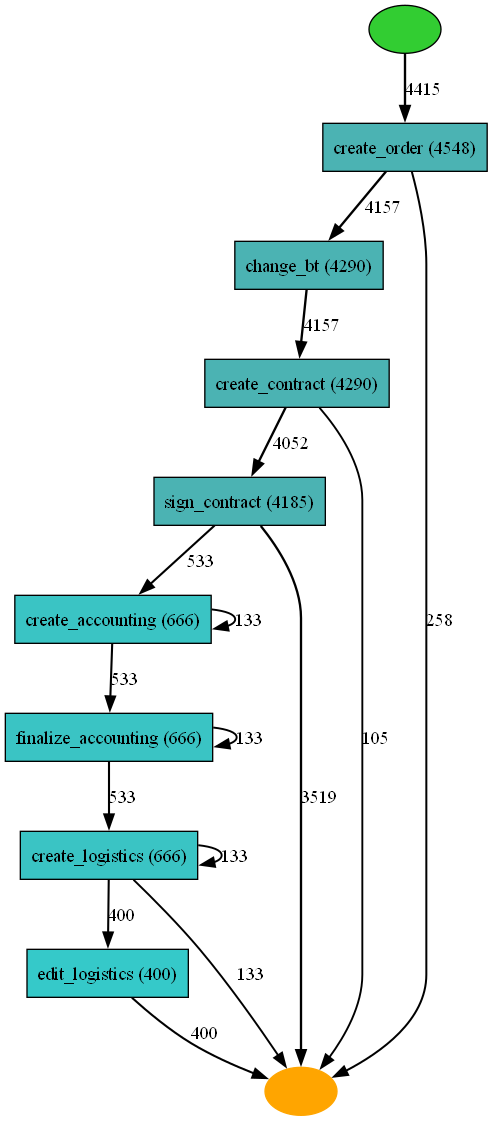

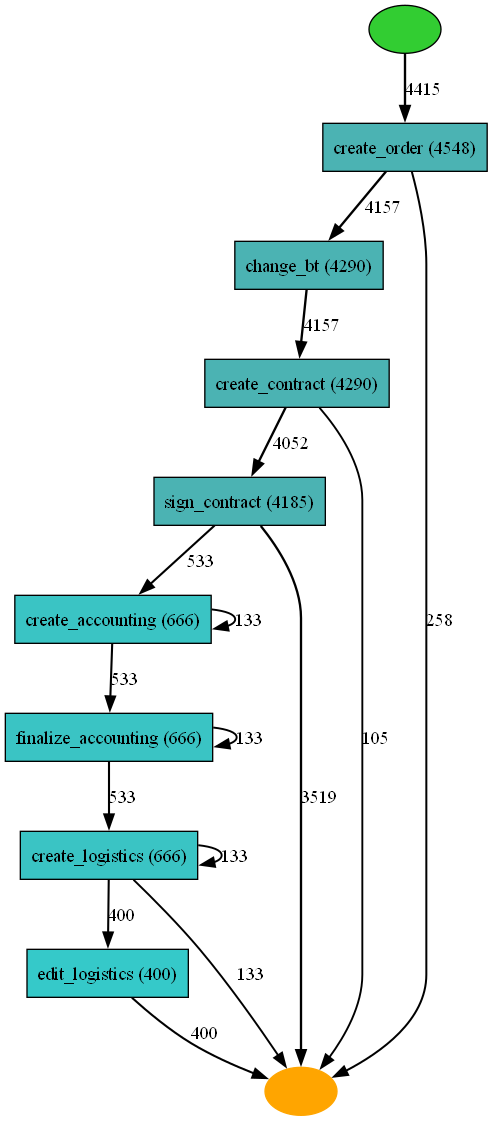

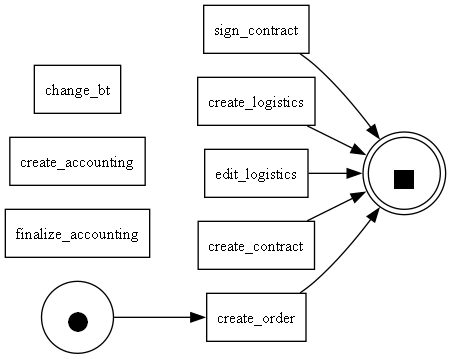

In [62]:
from pm4py.visualization.heuristics_net import visualizer
from pm4py.visualization.petri_net import visualizer as pn_visualizer

gviz = visualizer.apply(heu_net)
visualizer.view(gviz)

gviz = visualizer.apply(heu_net2)
visualizer.view(gviz)

gviz_alpha = pn_visualizer.apply(net, im, fm)
pn_visualizer.view(gviz_alpha)

## References
[1] Weijters, A. J. M. M., Wil MP van Der Aalst, and AK Alves De Medeiros. “Process mining with the heuristics miner-algorithm.” Technische Universiteit Eindhoven, Tech. Rep. WP 166 (2006): 1-34.

[2] van der Aalst, W M P and Weijters, A J M M and Maruster, L (2004). "Workflow Mining: Discovering process models from event logs", IEEE Transactions on Knowledge and Data Engineering, vol 16